In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([1, 1, 1, 0])


In [3]:
np.random.seed(7)

weights = np.random.uniform(-1, 1, size=2).astype(float)
bias = -0.5   # NAND-friendly bias

learning_rate = 0.2
max_epochs = 20


In [4]:
def step_function(z):
    return 1 if z >= 0 else 0

def predict(x):
    return step_function(np.dot(x, weights) + bias)


In [5]:
accuracy_history = []
weight_history = []
bias_history = []

epoch = 0

while epoch < max_epochs:
    epoch += 1
    print(f"\n=========== EPOCH {epoch} ===========\n")
    
    epoch_data = []
    correct = 0
    
    for xi, target in zip(X, y):
        prediction = predict(xi)
        error = target - prediction
        
        # Update rule
        weights[:] = weights + learning_rate * error * xi
        bias += learning_rate * error
        
        if prediction == target:
            correct += 1
        
        epoch_data.append([xi[0], xi[1], prediction, target, error])
    
    accuracy = correct / len(y)
    accuracy_history.append(accuracy)
    weight_history.append(weights.copy())
    bias_history.append(bias)
    
    df = pd.DataFrame(
        epoch_data,
        columns=["X1", "X2", "Predicted", "Target", "Error"]
    )
    print(df)
    print(f"\nAccuracy = {accuracy*100:.2f}%")
    
    if accuracy == 1.0:
        print("\n 100% Accuracy Achieved ")
        break
    
    time.sleep(1)



=========== EPOCH 1 ===========

   X1  X2  Predicted  Target  Error
0   0   0          0       1      1
1   0   1          1       1      0
2   1   0          0       1      1
3   1   1          0       0      0

Accuracy = 50.00%

=========== EPOCH 2 ===========

   X1  X2  Predicted  Target  Error
0   0   0          0       1      1
1   0   1          1       1      0
2   1   0          0       1      1
3   1   1          1       0     -1

Accuracy = 25.00%

=========== EPOCH 3 ===========

   X1  X2  Predicted  Target  Error
0   0   0          1       1      0
1   0   1          1       1      0
2   1   0          0       1      1
3   1   1          1       0     -1

Accuracy = 50.00%

=========== EPOCH 4 ===========

   X1  X2  Predicted  Target  Error
0   0   0          1       1      0
1   0   1          1       1      0
2   1   0          0       1      1
3   1   1          1       0     -1

Accuracy = 50.00%

=========== EPOCH 5 ===========

   X1  X2  Predicted  Target  Erro

In [6]:
print("\nFinal Weights & Bias:")
print(f"w1 = {weights[0]:.4f}")
print(f"w2 = {weights[1]:.4f}")
print(f"bias = {bias:.4f}")



Final Weights & Bias:
w1 = -0.4474
w2 = -0.2402
bias = 0.5000


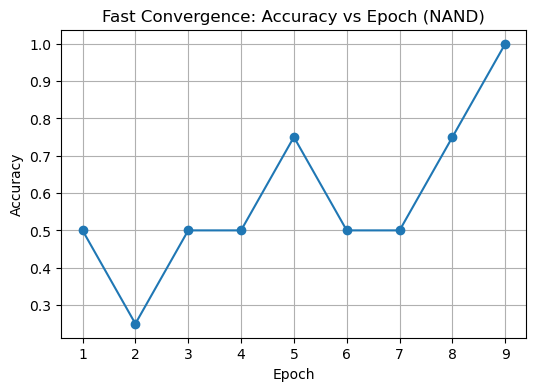

In [7]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(accuracy_history)+1),
         accuracy_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fast Convergence: Accuracy vs Epoch (NAND)")
plt.grid(True)
plt.show()


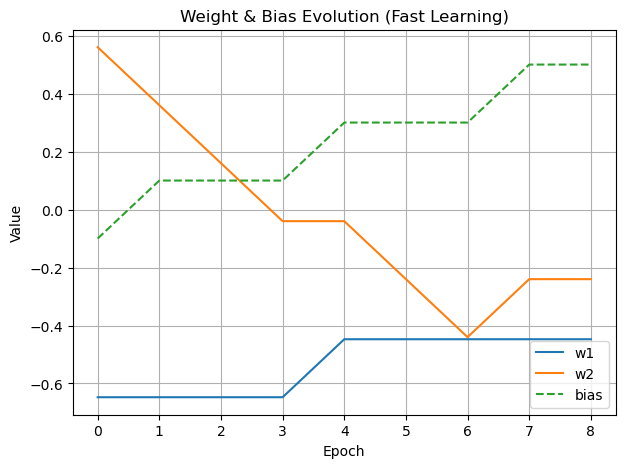

In [8]:
weight_history = np.array(weight_history)
bias_history = np.array(bias_history)

plt.figure(figsize=(7,5))
plt.plot(weight_history[:,0], label="w1")
plt.plot(weight_history[:,1], label="w2")
plt.plot(bias_history, label="bias", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Weight & Bias Evolution (Fast Learning)")
plt.legend()
plt.grid(True)
plt.show()


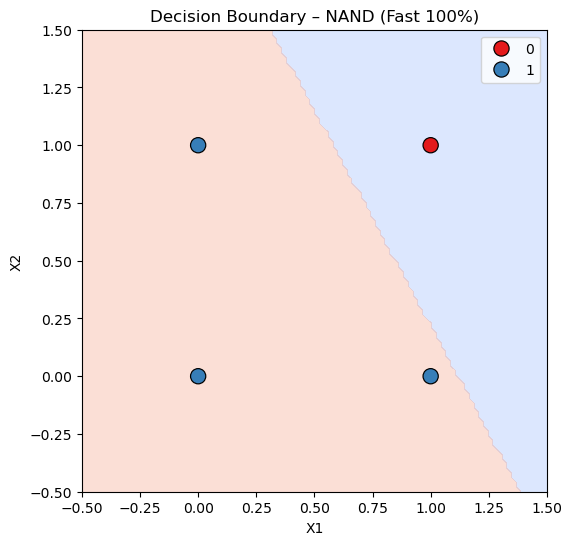

In [9]:
x1 = np.linspace(-0.5, 1.5, 100)
x2 = np.linspace(-0.5, 1.5, 100)
xx1, xx2 = np.meshgrid(x1, x2)

Z = np.dot(np.c_[xx1.ravel(), xx2.ravel()], weights) + bias
Z = Z.reshape(xx1.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx1, xx2, Z >= 0, alpha=0.3, cmap='coolwarm')

sns.scatterplot(
    x=X[:,0], y=X[:,1],
    hue=y, s=120,
    palette="Set1", edgecolor="k"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Decision Boundary – NAND (Fast 100%)")
plt.show()


In [10]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])  # XOR output


In [11]:
# Safe initialization (avoids 0% accuracy)
weights = np.array([1.0, 1.0], dtype=float)
bias = -0.5

learning_rate = 0.2
epochs = 10


In [12]:
def step_function(z):
    return 1 if z >= 0 else 0

def predict(x):
    return step_function(np.dot(x, weights) + bias)


In [13]:
accuracy_history = []
weight_history = []
bias_history = []

for epoch in range(1, epochs + 1):
    print(f"\n=========== EPOCH {epoch} ===========\n")
    
    epoch_data = []
    correct = 0
    
    for xi, target in zip(X, y):
        prediction = predict(xi)
        error = target - prediction
        
        # Perceptron learning rule
        weights[:] = weights + learning_rate * error * xi
        bias += learning_rate * error
        
        if prediction == target:
            correct += 1
        
        epoch_data.append([xi[0], xi[1], prediction, target, error])
    
    accuracy = correct / len(y)
    accuracy_history.append(accuracy)
    weight_history.append(weights.copy())
    bias_history.append(bias)
    
    df = pd.DataFrame(
        epoch_data,
        columns=["X1", "X2", "Predicted", "Target", "Error"]
    )
    
    print(df)
    print(f"\nAccuracy = {accuracy*100:.2f}%")
    
    time.sleep(1)



=========== EPOCH 1 ===========

   X1  X2  Predicted  Target  Error
0   0   0          0       0      0
1   0   1          1       1      0
2   1   0          1       1      0
3   1   1          1       0     -1

Accuracy = 75.00%

=========== EPOCH 2 ===========

   X1  X2  Predicted  Target  Error
0   0   0          0       0      0
1   0   1          1       1      0
2   1   0          1       1      0
3   1   1          1       0     -1

Accuracy = 75.00%

=========== EPOCH 3 ===========

   X1  X2  Predicted  Target  Error
0   0   0          0       0      0
1   0   1          0       1      1
2   1   0          0       1      1
3   1   1          1       0     -1

Accuracy = 25.00%

=========== EPOCH 4 ===========

   X1  X2  Predicted  Target  Error
0   0   0          0       0      0
1   0   1          0       1      1
2   1   0          1       1      0
3   1   1          1       0     -1

Accuracy = 50.00%

=========== EPOCH 5 ===========

   X1  X2  Predicted  Target  Erro

In [14]:
print("\nFinal Learned Parameters:")
print(f"Weight w1 = {weights[0]:.4f}")
print(f"Weight w2 = {weights[1]:.4f}")
print(f"Bias      = {bias:.4f}")



Final Learned Parameters:
Weight w1 = 0.0000
Weight w2 = 0.2000
Bias      = -0.3000


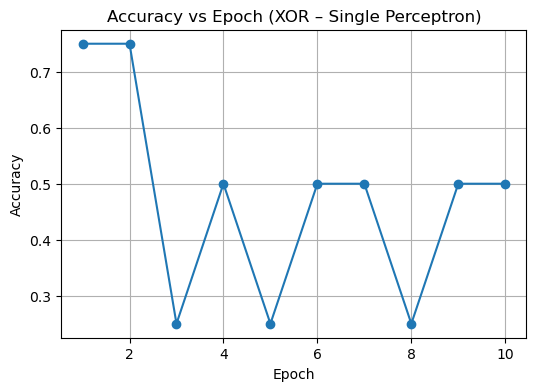

In [15]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(accuracy_history) + 1),
         accuracy_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch (XOR – Single Perceptron)")
plt.grid(True)
plt.show()


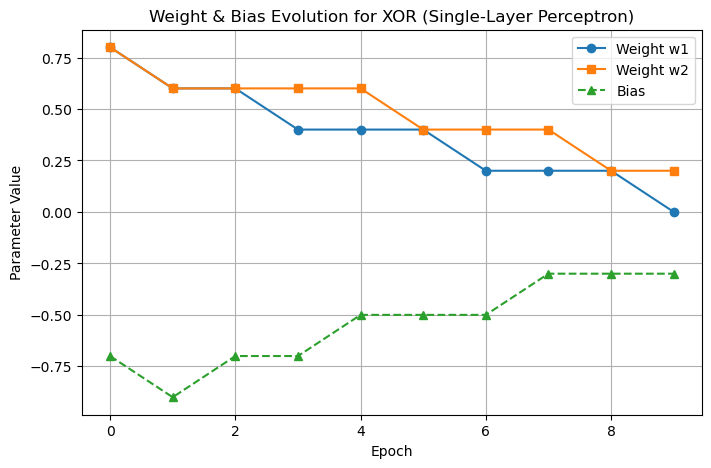

In [16]:
weight_history = np.array(weight_history)
bias_history = np.array(bias_history)

plt.figure(figsize=(8,5))
plt.plot(weight_history[:, 0], marker='o', label="Weight w1")
plt.plot(weight_history[:, 1], marker='s', label="Weight w2")
plt.plot(bias_history, marker='^', linestyle='--', label="Bias")

plt.xlabel("Epoch")
plt.ylabel("Parameter Value")
plt.title("Weight & Bias Evolution for XOR (Single-Layer Perceptron)")
plt.legend()
plt.grid(True)
plt.show()


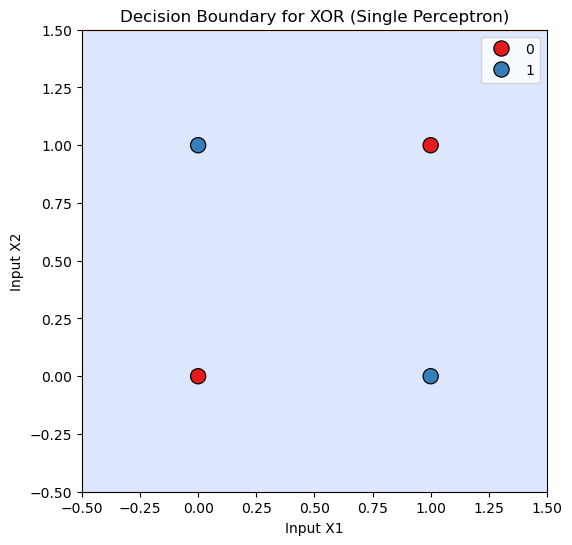

In [17]:
x1_vals = np.linspace(-0.5, 1.5, 100)
x2_vals = np.linspace(-0.5, 1.5, 100)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

Z = np.dot(np.c_[xx1.ravel(), xx2.ravel()], weights) + bias
Z = Z.reshape(xx1.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx1, xx2, Z >= 0, alpha=0.3, cmap='coolwarm')

sns.scatterplot(
    x=X[:,0], y=X[:,1],
    hue=y, s=120,
    palette="Set1", edgecolor='k'
)

plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.title("Decision Boundary for XOR (Single Perceptron)")
plt.show()
